# LLM API Cost Analysis for Text-to-SQL Tasks

This notebook calculates the average cost per task for different LLM models used in Text-to-SQL generation.

**Metrics Calculated:**
- Input token count (from prompts/instructions)
- Output token count (from generated SQL)
- Average cost per task (USD)
- Total cost per dataset and model

**Supported Models:**
- OpenAI: GPT-4o, GPT-4o-mini, GPT-5, GPT-5-mini
- DeepSeek: deepseek-chat, deepseek-coder
- Google: Gemini Pro, Gemma models
- Anthropic: Claude models

## 1. Import Required Libraries

In [1]:
import json
import os
from pathlib import Path
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For token counting
try:
    import tiktoken
    TIKTOKEN_AVAILABLE = True
except ImportError:
    print("Warning: tiktoken not installed. Using character-based approximation.")
    print("Install with: pip install tiktoken")
    TIKTOKEN_AVAILABLE = False

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")
print(f"✓ Tiktoken available: {TIKTOKEN_AVAILABLE}")

✓ Libraries imported successfully
✓ Tiktoken available: True


## 2. Define Model Pricing Configuration

Pricing as of October 2025 (USD per 1M tokens)

In [2]:
# Model pricing in USD per 1M tokens
# Format: {"model_name": {"input": price_per_1m_input_tokens, "output": price_per_1m_output_tokens}}

MODEL_PRICING = {
    # OpenAI Models
    # "gpt-4o": {"input": 2.50, "output": 10.00},
    "gpt-4o-mini": {"input": 0.15, "output": 0.60},
    # "gpt-4-turbo": {"input": 10.00, "output": 30.00},
    # "gpt-4": {"input": 30.00, "output": 60.00},
    # "gpt-3.5-turbo": {"input": 0.50, "output": 1.50},
    "gpt-5": {"input": 1.25, "output": 10.00},  # Estimated
    "gpt-5-mini": {"input": 0.25, "output": 2.00},  # Estimated
    
    # Anthropic Claude Models
    "claude-sonnet-4-5": {"input": 3.00, "output": 15.00},  # Latest Claude Sonnet 4.5
    # "claude-sonnet-4": {"input": 3.00, "output": 15.00},
    # "claude-3-5-sonnet-20241022": {"input": 3.00, "output": 15.00},
    # "claude-3-5-sonnet-20240620": {"input": 3.00, "output": 15.00},
    # "claude-3-opus-20240229": {"input": 15.00, "output": 75.00},
    # "claude-3-sonnet-20240229": {"input": 3.00, "output": 15.00},
    # "claude-3-haiku-20240307": {"input": 0.25, "output": 1.25},

    # Google Gemini
    "gemini-2.5-pro": {"input": 2.5, "output": 15.00},
    "gemini-2.5-flash": {"input": 0.3, "output": 2.50},
    # "gemini-2.0-flash-exp": {"input": 0.00, "output": 0.00},  # Free during preview
    # "gemini-1.5-pro-latest": {"input": 1.25, "output": 5.00},
    # "gemini-1.5-flash-latest": {"input": 0.075, "output": 0.30},
    # "gemini-1.5-flash-002": {"input": 0.075, "output": 0.30},
    # "gemini-1.5-pro-002": {"input": 1.25, "output": 5.00},
    
    # DeepSeek Models
    # "deepseek-chat": {"input": 0.28, "output": 0.42},
    "deepseek-coder": {"input": 0.28, "output": 0.42},
    "deepseek-reasoner": {"input": 0.28, "output": 0.42},
    
    # Google Models (via DeepInfra)
    "google-gemma-3-4b-it": {"input": 0.04, "output": 0.08},
    "google-gemma-3-27b-it": {"input": 0.09, "output": 0.16},
    
    # # Meta LLaMA Models (via DeepInfra)
    # "meta-llama/Meta-Llama-3.1-8B-Instruct": {"input": 0.06, "output": 0.06},
    # "meta-llama/Meta-Llama-3.1-70B-Instruct": {"input": 0.35, "output": 0.40},
    # "meta-llama/Meta-Llama-3.1-405B-Instruct": {"input": 2.70, "output": 2.70},
    
    # Qwen Models (via DeepInfra)
    "qwen2.5-coder-7b": {"input": 0.14, "output": 0.28},
    "qwen2.5-coder-7b-instruct": {"input": 0.14, "output": 0.28},
    "qwen2.5-14b": {"input": 0.14, "output": 0.42},
    
    # Specialized SQL Models
    # "defog/llama-3-sqlcoder-8b": {"input": 0.06, "output": 0.06},  # Via DeepInfra
    # "Snowflake/Arctic-Text2SQL-R1-7B": {"input": 0.06, "output": 0.06},  # Via DeepInfra
}

# Display pricing table
pricing_df = pd.DataFrame.from_dict(MODEL_PRICING, orient='index')
pricing_df = pricing_df.reset_index().rename(columns={'index': 'Model'})
pricing_df['Total (input+output)'] = pricing_df['input'] + pricing_df['output']
pricing_df = pricing_df.sort_values('Total (input+output)')

print("=" * 80)
print("MODEL PRICING CONFIGURATION (USD per 1M tokens)")
print("=" * 80)
display(pricing_df.style.format({
    'input': '${:.2f}',
    'output': '${:.2f}',
    'Total (input+output)': '${:.2f}'
}).background_gradient(subset=['Total (input+output)'], cmap='RdYlGn_r'))

MODEL PRICING CONFIGURATION (USD per 1M tokens)


,Model,input,output,Total (input+output)
8,google-gemma-3-4b-it,$0.04,$0.08,$0.12
9,google-gemma-3-27b-it,$0.09,$0.16,$0.25
11,qwen2.5-coder-7b-instruct,$0.14,$0.28,$0.42
10,qwen2.5-coder-7b,$0.14,$0.28,$0.42
12,qwen2.5-14b,$0.14,$0.42,$0.56
6,deepseek-coder,$0.28,$0.42,$0.70
7,deepseek-reasoner,$0.28,$0.42,$0.70
0,gpt-4o-mini,$0.15,$0.60,$0.75
2,gpt-5-mini,$0.25,$2.00,$2.25
5,gemini-2.5-flash,$0.30,$2.50,$2.80


## 3. Token Counting Functions

In [3]:
def count_tokens(text: str, model: str = "gpt-4") -> int:
    """
    Count tokens in text using tiktoken (if available) or character approximation.
    
    Args:
        text: Input text string
        model: Model name for selecting appropriate tokenizer
    
    Returns:
        Token count (int)
    """
    if not text:
        return 0
    
    if TIKTOKEN_AVAILABLE:
        try:
            # Use cl100k_base encoding for GPT-4, GPT-3.5-turbo, and similar models
            if any(m in model.lower() for m in ['gpt-4', 'gpt-3.5', 'gpt-5']):
                encoding = tiktoken.get_encoding("cl100k_base")
            else:
                # For other models, use cl100k_base as a reasonable approximation
                encoding = tiktoken.get_encoding("cl100k_base")
            
            return len(encoding.encode(text))
        except Exception as e:
            print(f"Warning: tiktoken encoding failed: {e}. Using approximation.")
            return len(text) // 4  # Rough approximation: 1 token ≈ 4 characters
    else:
        # Character-based approximation when tiktoken is not available
        return len(text) // 4


def count_tokens_batch(texts: List[str], model: str = "gpt-4") -> List[int]:
    """Count tokens for a batch of texts."""
    return [count_tokens(text, model) for text in texts]


# Test the function
test_text = "SELECT * FROM employees WHERE department = 'Engineering'"
test_tokens = count_tokens(test_text)
print(f"Test SQL: '{test_text}'")
print(f"Token count: {test_tokens}")
print(f"Character count: {len(test_text)}")
print(f"Ratio: {len(test_text)/test_tokens:.2f} chars/token")

Test SQL: 'SELECT * FROM employees WHERE department = 'Engineering''
Token count: 10
Character count: 56
Ratio: 5.60 chars/token


## 4. Load Datasets and Prediction Files

In [4]:
# Define paths - Updated for new RBAC experiment structure
from pathlib import Path

DATA_DIR_BASE = Path("../data/selected")  # Use relative path from notebooks directory
PRED_DIR_BASE = Path("../rbac-exp/output/pred/final")
PRED_DIR_RBAC = PRED_DIR_BASE / "rbac-result"
PRED_DIR_BASELINE = PRED_DIR_BASE / "baseline-result"

# Dataset configurations - Using column-level RBAC datasets
DATASETS = {
    # Column-level RBAC datasets for all three benchmarks
    "spider_rbac": DATA_DIR_BASE / "spider" / "column_level_rbac_dataset_spider_20260113.json",
    "bird_rbac": DATA_DIR_BASE / "bird" / "column_level_rbac_dataset_bird_filtered_schema_20260111.json",
    "livesqlbench_rbac": DATA_DIR_BASE / "livesqlbench-full" / "crud_rbac_dataset_v2_20251230.json",
}

def load_dataset(dataset_path: Path) -> List[Dict]:
    """Load a JSON dataset file."""
    with open(dataset_path, 'r') as f:
        data = json.load(f)
    return data

def find_prediction_files(pred_dirs: List[Path]) -> Dict[str, List[Path]]:
    """
    Find all prediction SQL files in multiple output directories.
    
    Returns:
        Dict mapping directory names to lists of prediction files
    """
    results = {}
    for pred_dir in pred_dirs:
        if pred_dir.exists():
            files = list(pred_dir.glob("pred_*.sql"))
            results[pred_dir.name] = files
        else:
            print(f"⚠ Directory not found: {pred_dir}")
            results[pred_dir.name] = []
    return results

# Load datasets
dataset_data = {}
for name, path in DATASETS.items():
    if path.exists():
        dataset_data[name] = load_dataset(path)
        print(f"✓ Loaded {name}: {len(dataset_data[name])} samples from {path.name}")
    else:
        print(f"✗ Dataset not found: {path}")
        
# Find prediction files in both directories
pred_files_by_dir = find_prediction_files([PRED_DIR_RBAC, PRED_DIR_BASELINE])

total_files = sum(len(files) for files in pred_files_by_dir.values())
print(f"\n{'='*80}")
print(f"PREDICTION FILES SUMMARY")
print(f"{'='*80}")
for dir_name, files in pred_files_by_dir.items():
    print(f"✓ {dir_name}: {len(files)} files")
    
print(f"\nTotal: {total_files} prediction files")

print(f"\n{'='*80}")
print("Sample prediction files from each directory:")
print(f"{'='*80}")
for dir_name, files in pred_files_by_dir.items():
    print(f"\n[{dir_name}]")
    for f in sorted(files)[:5]:
        print(f"  - {f.name}")

✓ Loaded spider_rbac: 5047 samples from column_level_rbac_dataset_spider_20260113.json
✓ Loaded bird_rbac: 7252 samples from column_level_rbac_dataset_bird_filtered_schema_20260111.json
✓ Loaded livesqlbench_rbac: 3217 samples from crud_rbac_dataset_v2_20251230.json

PREDICTION FILES SUMMARY
✓ rbac-result: 48 files
✓ baseline-result: 38 files

Total: 86 prediction files

Sample prediction files from each directory:

[rbac-result]
  - pred_2020dfff-llama3-sqlcoder_bird_structured_rbac.sql
  - pred_2020dfff-llama3-sqlcoder_spider_structured_rbac.sql
  - pred_2020dfff-snowflake-text2sql_bird_structured_rbac_role-schema.sql
  - pred_anthropic-claude-sonnet-4.5_bird_structured_rbac.sql
  - pred_anthropic-claude-sonnet-4.5_livesqlbench_structured_rbac.sql

[baseline-result]
  - pred_2020dfff-llama3-sqlcoder_bird_structured_baseline.sql
  - pred_2020dfff-llama3-sqlcoder_spider_structured_baseline.sql
  - pred_anthropic-claude-sonnet-4.5_bird_structured_baseline.sql
  - pred_anthropic-claude-s

## 5. Calculate Token Counts and Costs

In [5]:
# ============================================================================
# Cost Analysis Functions
# ============================================================================

# Filename pattern to model name mapping
# Format: filename_pattern -> pricing_key
FILENAME_MODEL_MAPPING = {
    # OpenAI models
    "gpt-4o-mini": "gpt-4o-mini",
    "gpt-5-mini": "gpt-5-mini",
    "gpt-5": "gpt-5",
    
    # Anthropic models
    "anthropic-claude-sonnet-4.5": "claude-sonnet-4-5",
    "claude-sonnet-4-5": "claude-sonnet-4-5",
    
    # Google models
    "gemini-2.5-flash": "gemini-2.5-flash",
    "gemini-2.5-pro": "gemini-2.5-pro",
    "google-gemma-3-27b-it": "google-gemma-3-27b-it",
    "google-gemma-3-4b-it": "google-gemma-3-4b-it",
    
    # DeepSeek models
    "deepseek-reasoner": "deepseek-reasoner",
    "deepseek-coder": "deepseek-coder",
    "deepseek-chat": "deepseek-coder",  # Map to deepseek-coder pricing
    
    # Qwen models
    "qwen2.5-coder-7b-instruct": "qwen2.5-coder-7b-instruct",
    "qwen2-5-coder-7b-instruct": "qwen2.5-coder-7b-instruct",  # Handle dash in filename
    "qwen2.5-14b-instruct": "qwen2.5-14b",
    "qwen2-5-14b-instruct": "qwen2.5-14b",  # Handle dash in filename
    
    # Local/Fine-tuned models (skip - no pricing)
    "arctic-text2sql-r1-7b": None,
    "2020dfff-llama3-sqlcoder": None,
    "llama-3-sqlcoder-8b": None,
}

def extract_model_name(filename: str) -> str:
    """
    Extract model name from prediction filename using explicit mapping.
    
    Handles various formats:
    - pred_{model}_{dataset}_structured_rbac.sql
    - pred_{model}_{dataset}_structured_baseline.sql
    - pred_{model}_{dataset}_rbac.sql
    - pred_{model}_{dataset}_baseline.sql
    
    Returns:
        Model name that matches MODEL_PRICING keys, or None if unmapped/local model
    """
    # Remove common prefixes/suffixes
    name = filename.replace("pred_", "").replace(".sql", "").replace("_cleaned", "")
    
    # Try exact matches first (for full filename patterns)
    for pattern, model_key in FILENAME_MODEL_MAPPING.items():
        if name.startswith(pattern + "_"):
            return model_key
    
    # Extract candidate model name (before dataset/mode keywords)
    parts = name.split("_")
    candidate_parts = []
    for part in parts:
        # Stop at dataset/mode/variant keywords
        if part in ["spider", "bird", "livesqlbench", "structured", "rbac", "baseline", "role", "schema", "table", "base", "sft"]:
            break
        candidate_parts.append(part)
    
    candidate = "_".join(candidate_parts) if candidate_parts else parts[0]
    
    # Try mapping the candidate
    if candidate in FILENAME_MODEL_MAPPING:
        return FILENAME_MODEL_MAPPING[candidate]
    
    # Try partial matching for complex names
    for pattern, model_key in FILENAME_MODEL_MAPPING.items():
        if pattern in candidate:
            return model_key
    
    # If no mapping found, return candidate (will be skipped later if no pricing)
    return candidate


def extract_mode(filename: str) -> str:
    """
    Extract mode (rbac/baseline) from prediction filename.
    
    Returns:
        'rbac', 'baseline', or 'unknown'
    """
    if "_rbac" in filename or filename.endswith("rbac.sql"):
        return "rbac"
    elif "_baseline" in filename or filename.endswith("baseline.sql"):
        return "baseline"
    else:
        return "unknown"


def analyze_cost(dataset_name: str, pred_file: Path, dataset: List[Dict], mode: str = None) -> Dict:
    """
    Analyze cost for a specific model prediction on a dataset.
    
    Args:
        dataset_name: Name of the dataset
        pred_file: Path to prediction file
        dataset: Dataset samples
        mode: Prediction mode ('rbac', 'baseline', or auto-detect from filename)
    
    Returns:
        Dict with token counts and cost analysis, or None if pricing not found
    """
    model_name = extract_model_name(pred_file.name)
    
    # Skip if model is unmapped (local model)
    if model_name is None:
        return None
    
    # Auto-detect mode from filename if not provided
    if mode is None:
        mode = extract_mode(pred_file.name)
    
    # Check if pricing exists
    if model_name not in MODEL_PRICING:
        return None
    
    pricing = MODEL_PRICING[model_name]
    
    # Load detailed.json file for raw_response (actual LLM output)
    detailed_file = pred_file.parent / pred_file.name.replace(".sql", "_detailed.json")
    raw_responses = {}
    
    if detailed_file.exists():
        try:
            with open(detailed_file, 'r') as f:
                detailed_data = json.load(f)
                # Build mapping from question to raw_response
                for item in detailed_data:
                    question = item.get("question", "")
                    raw_response = item.get("raw_response", "")
                    if question:
                        raw_responses[question] = raw_response
        except Exception as e:
            print(f"    ⚠️  Warning: Failed to load {detailed_file.name}: {e}")
    else:
        print(f"    ⚠️  Warning: Detailed file not found: {detailed_file.name}")
    
    # Calculate total tokens based on mode
    total_input_tokens = 0
    total_output_tokens = 0
    num_samples_with_response = 0
    
    for sample in dataset:
        instruction = sample.get("instruction", "")
        user_input = sample.get("input", "")
        question = sample.get("question", "")
        
        # Build prompt based on mode
        if mode == "rbac":
            role = sample.get("role", "")
            tables = sample.get("tables", "")
            prompt = f"{instruction}\n{user_input}\nRole: {role}\nAccessible Tables: {tables}"
        else:  # baseline mode
            prompt = f"{instruction}\n{user_input}"
        
        # Count input tokens
        input_tokens = count_tokens(prompt)
        total_input_tokens += input_tokens
        
        # Count output tokens from raw_response (actual LLM output)
        if question and question in raw_responses:
            raw_response = raw_responses[question]
            output_tokens = count_tokens(raw_response)
            num_samples_with_response += 1
        else:
            # Fallback to dataset output if raw_response not available
            output = sample.get("output", "SELECT 1")
            output_tokens = count_tokens(output)
        
        total_output_tokens += output_tokens
    
    # Calculate costs
    input_cost = (total_input_tokens / 1_000_000) * pricing["input"]
    output_cost = (total_output_tokens / 1_000_000) * pricing["output"]
    total_cost = input_cost + output_cost
    
    return {
        "model": model_name,
        "dataset": dataset_name,
        "mode": mode,
        "pred_file": pred_file.name,
        "num_samples": len(dataset),
        "num_samples_with_raw_response": num_samples_with_response,
        "total_input_tokens": total_input_tokens,
        "total_output_tokens": total_output_tokens,
        "avg_input_tokens": total_input_tokens / len(dataset) if dataset else 0,
        "avg_output_tokens": total_output_tokens / len(dataset) if dataset else 0,
        "input_cost_usd": input_cost,
        "output_cost_usd": output_cost,
        "total_cost_usd": total_cost,
        "cost_per_sample_usd": total_cost / len(dataset) if dataset else 0,
    }

print("✓ Cost analysis functions defined")
print(f"  - Configured pricing for {len(MODEL_PRICING)} models")
print(f"  - Filename mappings: {len(FILENAME_MODEL_MAPPING)} patterns")

✓ Cost analysis functions defined
  - Configured pricing for 13 models
  - Filename mappings: 19 patterns


In [6]:
# Analyze all prediction files from both RBAC and Baseline directories
results = []
skipped_no_pricing = []

# Process files from both directories
for dir_name, pred_files in pred_files_by_dir.items():
    # Determine mode from directory name
    mode = "rbac" if "rbac" in dir_name.lower() else "baseline" if "baseline" in dir_name.lower() else "unknown"
    
    print(f"\n{'='*80}")
    print(f"Processing {dir_name} ({mode.upper()} mode)")
    print(f"{'='*80}")
    
    for pred_file in pred_files:
        filename = pred_file.name
        
        # Skip cleaned files (we want original predictions)
        if "_cleaned" in filename:
            continue
        
        # Skip special experiment variants (role-schema, role-table, sft, _base.)
        # We only want standard rbac and baseline predictions
        special_variants = ["role-schema", "role-table", "sft", "_base."]
        if any(variant in filename.lower() for variant in special_variants):
            skipped_no_pricing.append(f"{filename} (special variant)")
            continue
        
        # Determine which dataset this prediction belongs to
        dataset_name = None
        
        # Match prediction file to dataset based on filename
        if "spider" in filename.lower():
            dataset_name = "spider_rbac"
        elif "bird" in filename.lower():
            dataset_name = "bird_rbac"
        elif "livesqlbench" in filename.lower():
            dataset_name = "livesqlbench_rbac"
        
        if dataset_name and dataset_name in dataset_data:
            print(f"  Analyzing: {filename} → {dataset_name} ({mode})")
            try:
                result = analyze_cost(dataset_name, pred_file, dataset_data[dataset_name], mode=mode)
                if result is not None:
                    results.append(result)
                else:
                    # No pricing found for this model
                    model_name = extract_model_name(filename)
                    skipped_no_pricing.append(f"{filename} (model: {model_name})")
                    print(f"    ⚠️  Skipped: No pricing configured for model '{model_name}'")
            except Exception as e:
                print(f"    ❌ Error: {e}")
        else:
            # Skip files that don't match expected patterns
            pass

print(f"\n{'='*80}")
print(f"ANALYSIS SUMMARY")
print(f"{'='*80}")
print(f"✓ Analyzed {len(results)} prediction files")
print(f"  - RBAC mode: {sum(1 for r in results if r['mode'] == 'rbac')}")
print(f"  - Baseline mode: {sum(1 for r in results if r['mode'] == 'baseline')}")

if skipped_no_pricing:
    # Separate special variants from no-pricing files
    special_variant_files = [s for s in skipped_no_pricing if "(special variant)" in s]
    no_pricing_files = [s for s in skipped_no_pricing if "(special variant)" not in s]
    
    if special_variant_files:
        print(f"\n⚠️  Skipped {len(special_variant_files)} special variant files (sft, role-schema, etc.):")
        for skipped in special_variant_files[:5]:
            print(f"   - {skipped}")
        if len(special_variant_files) > 5:
            print(f"   ... and {len(special_variant_files) - 5} more")
    
    if no_pricing_files:
        print(f"\n⚠️  Skipped {len(no_pricing_files)} files (no pricing configured):")
        for skipped in no_pricing_files[:5]:
            print(f"   - {skipped}")
        if len(no_pricing_files) > 5:
            print(f"   ... and {len(no_pricing_files) - 5} more")

# Create DataFrame
cost_df = pd.DataFrame(results)
if len(cost_df) > 0:
    cost_df = cost_df.sort_values(['mode', 'model', 'cost_per_sample_usd'], ascending=[True, True, False])
    print(f"\n✅ Cost analysis completed for {len(cost_df)} model-dataset-mode combinations")
else:
    print("\n⚠️  No results to analyze")



Processing rbac-result (RBAC mode)
  Analyzing: pred_anthropic-claude-sonnet-4.5_livesqlbench_structured_rbac.sql → livesqlbench_rbac (rbac)
  Analyzing: pred_gpt-4o-mini_bird_structured_rbac.sql → bird_rbac (rbac)
  Analyzing: pred_deepseek-reasoner_bird_rbac.sql → bird_rbac (rbac)
  Analyzing: pred_2020dfff-llama3-sqlcoder_spider_structured_rbac.sql → spider_rbac (rbac)
    ⚠️  Skipped: No pricing configured for model 'None'
  Analyzing: pred_qwen2.5-coder-7b-instruct_spider_structured_rbac.sql → spider_rbac (rbac)
  Analyzing: pred_deepseek-reasoner_spider_rbac.sql → spider_rbac (rbac)
  Analyzing: pred_deepseek-reasoner_livesqlbench_rbac.sql → livesqlbench_rbac (rbac)
  Analyzing: pred_qwen2-5-14b-instruct_spider_rbac_structured.sql → spider_rbac (rbac)
  Analyzing: pred_google-gemma-3-4b-it_bird_structured_rbac.sql → bird_rbac (rbac)
  Analyzing: pred_anthropic-claude-sonnet-4.5_bird_structured_rbac.sql → bird_rbac (rbac)
  Analyzing: pred_gpt-5_spider_structured_rbac.sql → spide

## 6. Cost Analysis Results

In [7]:
# Display summary table with RBAC/Baseline comparison
if len(cost_df) > 0:
    summary_cols = [
        'model', 'dataset', 'mode', 'num_samples', 
        'avg_input_tokens', 'avg_output_tokens',
        'cost_per_sample_usd', 'total_cost_usd'
    ]
    
    display_df = cost_df[summary_cols].copy()
    
    # Convert cost_per_sample to USD * 10^-3 (multiply by 1000 to show in millidollars)
    display_df['cost_per_sample_usd_x1e3'] = display_df['cost_per_sample_usd'] * 1000
    
    # Define custom sort orders
    dataset_order = {'spider_rbac': 1, 'bird_rbac': 2, 'livesqlbench_rbac': 3}
    model_order = {
        # Snowflake
        'arctic-text2sql-r1-7b': 1,
        '2020dfff-llama3-sqlcoder': 2,
        'llama-3-sqlcoder-8b': 3,
        # Gemma
        'google-gemma-3-4b-it': 10,
        'google-gemma-3-27b-it': 11,
        # Qwen
        'qwen2.5-coder-7b': 20,
        'qwen2.5-coder-7b-instruct': 21,
        'qwen2.5-14b': 22,
        # DeepSeek
        'deepseek-coder': 30,
        'deepseek-reasoner': 31,
        # Claude
        'claude-sonnet-4-5': 40,
        # Gemini
        'gemini-2.5-flash': 50,
        'gemini-2.5-pro': 51,
        # GPT
        'gpt-4o-mini': 60,
        'gpt-5-mini': 61,
        'gpt-5': 62,
    }
    mode_order = {'baseline': 1, 'rbac': 2}
    
    # Add sort keys
    display_df['dataset_sort'] = display_df['dataset'].map(dataset_order).fillna(999)
    display_df['model_sort'] = display_df['model'].map(model_order).fillna(999)
    display_df['mode_sort'] = display_df['mode'].map(mode_order).fillna(999)
    
    # Sort by dataset, then model, then mode
    display_df = display_df.sort_values(['dataset_sort', 'model_sort', 'mode_sort'])
    
    # Drop sort columns
    display_df = display_df.drop(columns=['dataset_sort', 'model_sort', 'mode_sort'])
    
    # Reorder columns for display
    display_cols = [
        'model', 'mode', 'dataset', 'num_samples', 
        'avg_input_tokens', 'avg_output_tokens',
        'cost_per_sample_usd_x1e3', 'total_cost_usd'
    ]
    display_df = display_df[display_cols]
    
    print("=" * 120)
    print("COST ANALYSIS SUMMARY (RBAC vs Baseline)")
    print("=" * 120)
    
    # Format and display
    styled_df = display_df.style.format({
        'avg_input_tokens': '{:.0f}',
        'avg_output_tokens': '{:.0f}',
        'cost_per_sample_usd_x1e3': '{:.3f}',  # Now showing millidollars with 3 decimal places
        'total_cost_usd': '${:.4f}',
        'num_samples': '{:.0f}'
    }).background_gradient(
        subset=['cost_per_sample_usd_x1e3'], 
        cmap='RdYlGn_r'
    )
    
    display(styled_df)
    
    # Show mode-specific statistics
    print(f"\n{'='*120}")
    print("MODE COMPARISON STATISTICS")
    print(f"{'='*120}")
    
    for mode in ['rbac', 'baseline']:
        mode_df = cost_df[cost_df['mode'] == mode]
        if len(mode_df) > 0:
            print(f"\n{mode.upper()} Mode:")
            print(f"  Models analyzed: {mode_df['model'].nunique()}")
            print(f"  Total predictions: {mode_df['num_samples'].sum():.0f}")
            print(f"  Avg cost per sample: ${mode_df['cost_per_sample_usd'].mean():.6f}")
            print(f"  Total cost: ${mode_df['total_cost_usd'].sum():.4f}")
            print(f"  Avg input tokens: {mode_df['avg_input_tokens'].mean():.0f}")
            print(f"  Avg output tokens: {mode_df['avg_output_tokens'].mean():.0f}")
else:
    print("No results to display")

COST ANALYSIS SUMMARY (RBAC vs Baseline)


,model,mode,dataset,num_samples,avg_input_tokens,avg_output_tokens,cost_per_sample_usd_x1e3,total_cost_usd
37,google-gemma-3-4b-it,baseline,spider_rbac,5047,368,21,0.016,$0.0828
24,google-gemma-3-4b-it,rbac,spider_rbac,5047,378,21,0.017,$0.0848
54,google-gemma-3-27b-it,baseline,spider_rbac,5047,368,21,0.036,$0.1842
19,google-gemma-3-27b-it,rbac,spider_rbac,5047,378,21,0.037,$0.1886
52,qwen2.5-coder-7b-instruct,baseline,spider_rbac,5047,368,21,0.057,$0.2898
3,qwen2.5-coder-7b-instruct,rbac,spider_rbac,5047,378,21,0.059,$0.2966
51,qwen2.5-14b,baseline,spider_rbac,5047,368,21,0.060,$0.3047
6,qwen2.5-14b,rbac,spider_rbac,5047,378,21,0.062,$0.3115
57,deepseek-coder,baseline,spider_rbac,5047,368,21,0.112,$0.5648
17,deepseek-coder,rbac,spider_rbac,5047,378,21,0.115,$0.5784



MODE COMPARISON STATISTICS

RBAC Mode:
  Models analyzed: 11
  Total predictions: 170676
  Avg cost per sample: $0.002114
  Total cost: $258.7616
  Avg input tokens: 3702
  Avg output tokens: 42

BASELINE Mode:
  Models analyzed: 11
  Total predictions: 170676
  Avg cost per sample: $0.002109
  Total cost: $257.8786
  Avg input tokens: 3692
  Avg output tokens: 42


In [8]:
# RBAC vs Baseline Comparison for each model
if len(cost_df) > 0:
    print("=" * 120)
    print("RBAC vs BASELINE COST COMPARISON BY MODEL")
    print("=" * 120)
    
    # Group by model and mode
    comparison_data = []
    
    for model in cost_df['model'].unique():
        model_df = cost_df[cost_df['model'] == model]
        
        rbac_data = model_df[model_df['mode'] == 'rbac']
        baseline_data = model_df[model_df['mode'] == 'baseline']
        
        if len(rbac_data) > 0 and len(baseline_data) > 0:
            rbac_row = rbac_data.iloc[0]
            baseline_row = baseline_data.iloc[0]
            
            # Calculate differences
            input_token_diff = rbac_row['avg_input_tokens'] - baseline_row['avg_input_tokens']
            cost_diff = rbac_row['cost_per_sample_usd'] - baseline_row['cost_per_sample_usd']
            cost_diff_pct = (cost_diff / baseline_row['cost_per_sample_usd'] * 100) if baseline_row['cost_per_sample_usd'] > 0 else 0
            
            comparison_data.append({
                'model': model,
                'rbac_input_tokens': rbac_row['avg_input_tokens'],
                'baseline_input_tokens': baseline_row['avg_input_tokens'],
                'input_token_diff': input_token_diff,
                'rbac_cost': rbac_row['cost_per_sample_usd'] * 1000,  # in millidollars
                'baseline_cost': baseline_row['cost_per_sample_usd'] * 1000,
                'cost_diff': cost_diff * 1000,
                'cost_diff_pct': cost_diff_pct,
                'rbac_total_cost': rbac_row['total_cost_usd'],
                'baseline_total_cost': baseline_row['total_cost_usd'],
            })
    
    if comparison_data:
        comp_df = pd.DataFrame(comparison_data)
        comp_df = comp_df.sort_values('cost_diff_pct', ascending=False)
        
        styled_comp = comp_df.style.format({
            'rbac_input_tokens': '{:.0f}',
            'baseline_input_tokens': '{:.0f}',
            'input_token_diff': '{:+.0f}',
            'rbac_cost': '{:.3f}',
            'baseline_cost': '{:.3f}',
            'cost_diff': '{:+.3f}',
            'cost_diff_pct': '{:+.1f}%',
            'rbac_total_cost': '${:.4f}',
            'baseline_total_cost': '${:.4f}',
        }).background_gradient(
            subset=['cost_diff_pct'], 
            cmap='RdYlGn_r'
        )
        
        display(styled_comp)
        
        print(f"\n{'='*120}")
        print("SUMMARY STATISTICS")
        print(f"{'='*120}")
        print(f"Models with both modes: {len(comp_df)}")
        print(f"Avg RBAC overhead (input tokens): {comp_df['input_token_diff'].mean():+.0f} tokens")
        print(f"Avg RBAC cost increase: {comp_df['cost_diff_pct'].mean():+.2f}%")
        print(f"Max RBAC cost increase: {comp_df['cost_diff_pct'].max():+.2f}% ({comp_df.loc[comp_df['cost_diff_pct'].idxmax(), 'model']})")
        print(f"Min RBAC cost increase: {comp_df['cost_diff_pct'].min():+.2f}% ({comp_df.loc[comp_df['cost_diff_pct'].idxmin(), 'model']})")
    else:
        print("No models found with both RBAC and Baseline predictions")
else:
    print("No results to compare")

RBAC vs BASELINE COST COMPARISON BY MODEL


,model,rbac_input_tokens,baseline_input_tokens,input_token_diff,rbac_cost,baseline_cost,cost_diff,cost_diff_pct,rbac_total_cost,baseline_total_cost
1,deepseek-coder,9700,9690,+10,2.746,2.743,+0.003,+0.1%,$8.8334,$8.8247
2,deepseek-reasoner,9700,9690,+10,2.746,2.743,+0.003,+0.1%,$8.8334,$8.8247
4,google-gemma-3-27b-it,9700,9690,+10,0.884,0.884,+0.001,+0.1%,$2.8450,$2.8422
10,qwen2.5-coder-7b-instruct,9700,9690,+10,1.378,1.377,+0.001,+0.1%,$4.4327,$4.4283
5,google-gemma-3-4b-it,9700,9690,+10,0.394,0.393,+0.000,+0.1%,$1.2665,$1.2652
9,qwen2.5-14b,9700,9690,+10,1.388,1.386,+0.001,+0.1%,$4.4647,$4.4603
6,gpt-4o-mini,9700,9690,+10,1.498,1.496,+0.001,+0.1%,$4.8178,$4.8132
0,claude-sonnet-4-5,9700,9690,+10,30.165,30.136,+0.029,+0.1%,$97.0420,$96.9485
8,gpt-5-mini,9700,9690,+10,2.567,2.565,+0.002,+0.1%,$8.2581,$8.2503
7,gpt-5,9700,9690,+10,12.835,12.823,+0.012,+0.1%,$41.2906,$41.2517



SUMMARY STATISTICS
Models with both modes: 11
Avg RBAC overhead (input tokens): +10 tokens
Avg RBAC cost increase: +0.10%
Max RBAC cost increase: +0.10% (deepseek-coder)
Min RBAC cost increase: +0.09% (gemini-2.5-flash)


## 7. Visualizations

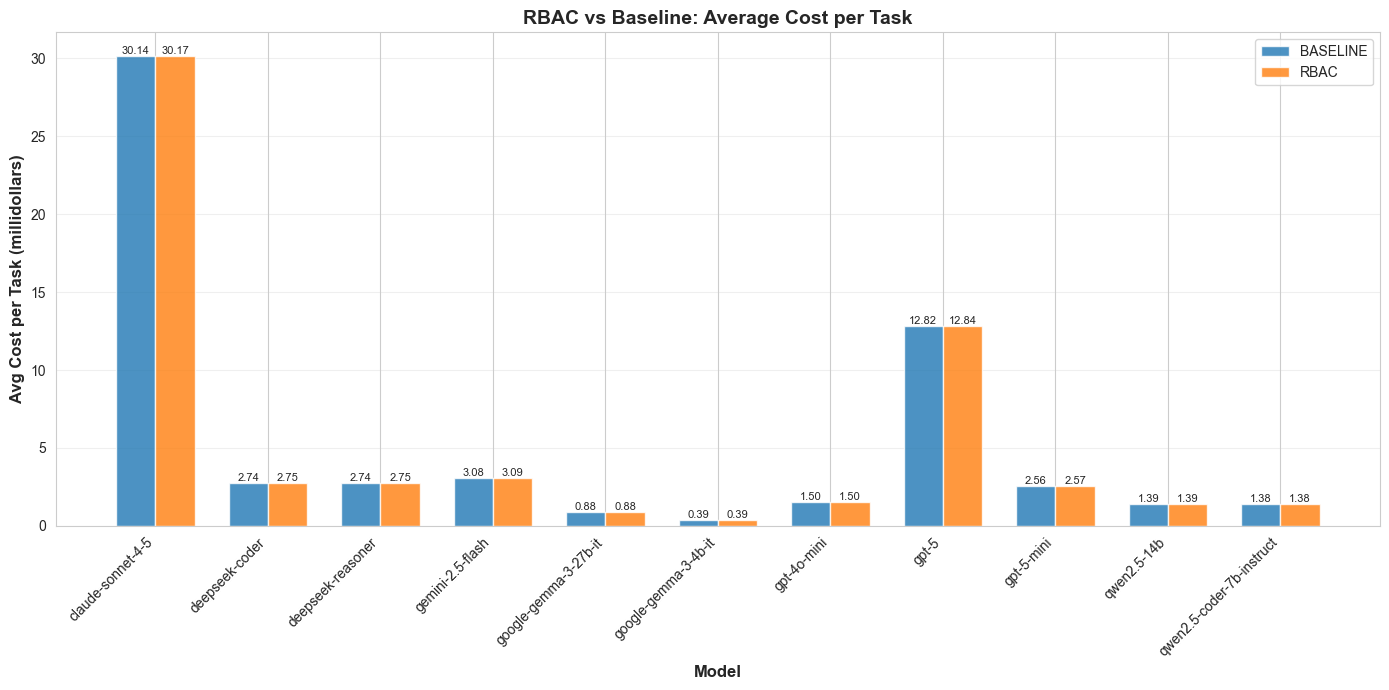

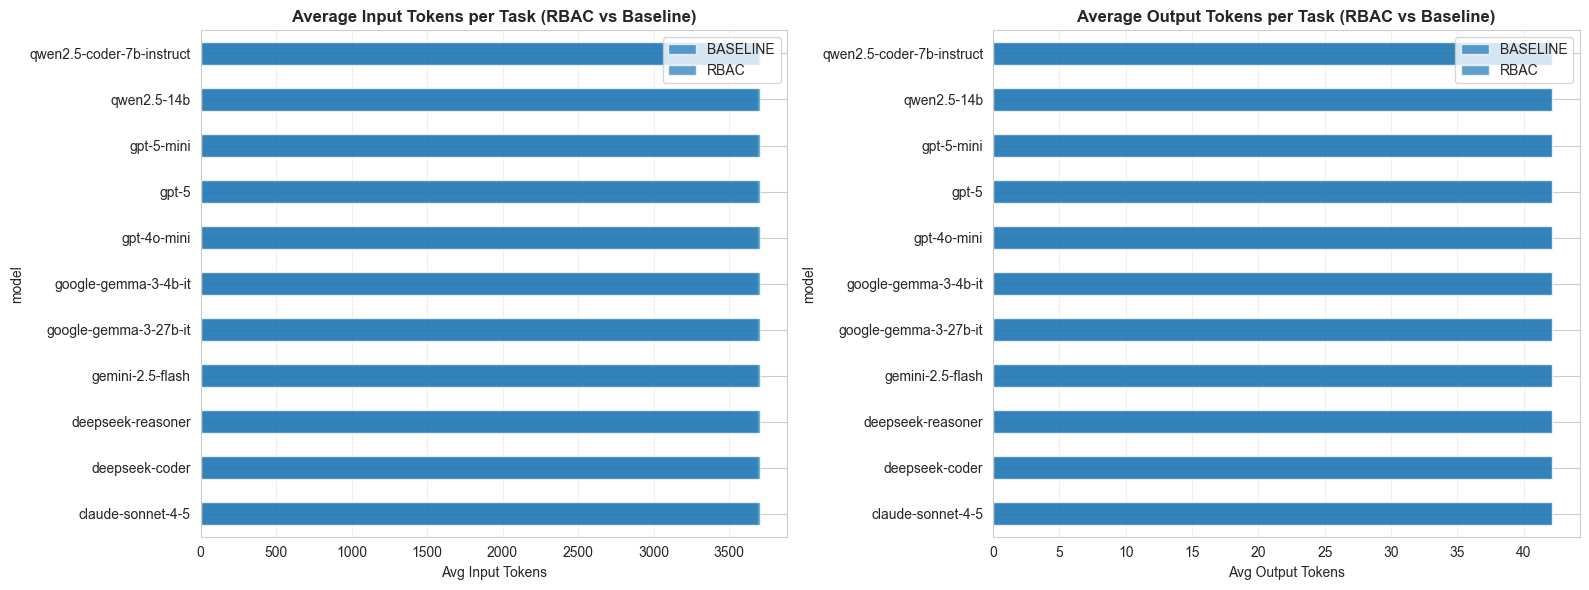

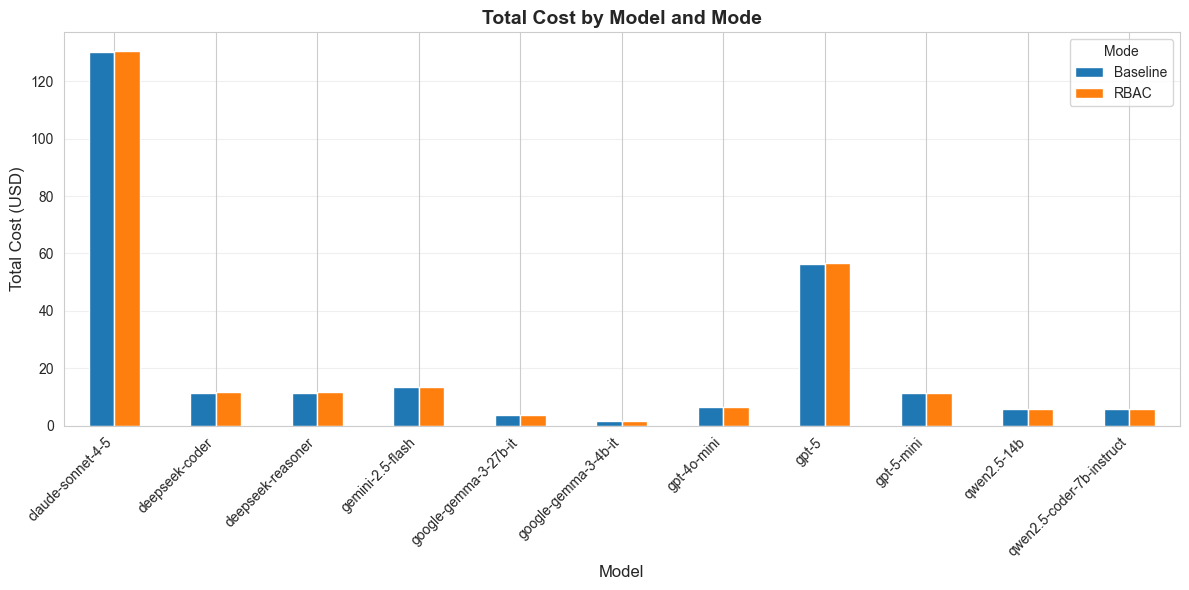

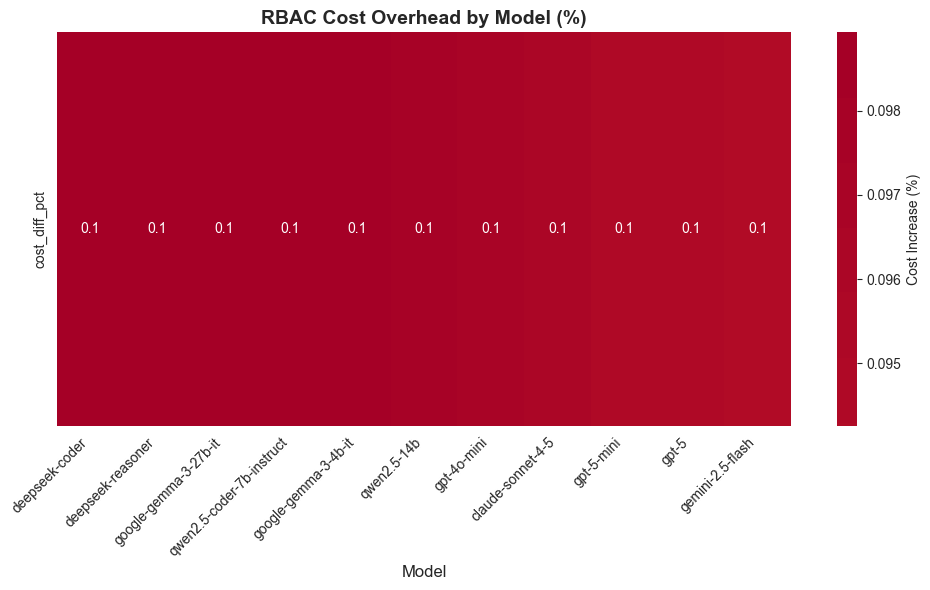

In [9]:
if len(cost_df) > 0:
    # 1. RBAC vs Baseline Cost Comparison
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Create grouped bar chart
    modes = cost_df['mode'].unique()
    models = sorted(cost_df['model'].unique())
    
    x = np.arange(len(models))
    width = 0.35
    
    for i, mode in enumerate(['baseline', 'rbac']):
        mode_data = cost_df[cost_df['mode'] == mode]
        costs = [mode_data[mode_data['model'] == m]['cost_per_sample_usd'].values[0] * 1000 
                 if len(mode_data[mode_data['model'] == m]) > 0 else 0 
                 for m in models]
        
        offset = width * (i - 0.5)
        bars = ax.bar(x + offset, costs, width, label=mode.upper(), alpha=0.8)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}',
                       ha='center', va='bottom', fontsize=8, rotation=0)
    
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Avg Cost per Task (millidollars)', fontsize=12, fontweight='bold')
    ax.set_title('RBAC vs Baseline: Average Cost per Task', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 2. Token Usage Comparison (RBAC vs Baseline)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Input tokens comparison
    for mode in ['baseline', 'rbac']:
        mode_data = cost_df[cost_df['mode'] == mode].groupby('model')['avg_input_tokens'].mean()
        mode_data.plot(kind='barh', ax=ax1, label=mode.upper(), alpha=0.7)
    
    ax1.set_title('Average Input Tokens per Task (RBAC vs Baseline)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Avg Input Tokens')
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    
    # Output tokens comparison
    for mode in ['baseline', 'rbac']:
        mode_data = cost_df[cost_df['mode'] == mode].groupby('model')['avg_output_tokens'].mean()
        mode_data.plot(kind='barh', ax=ax2, label=mode.upper(), alpha=0.7)
    
    ax2.set_title('Average Output Tokens per Task (RBAC vs Baseline)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Avg Output Tokens')
    ax2.legend()
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Total Cost Comparison by Mode
    fig, ax = plt.subplots(figsize=(12, 6))
    
    mode_totals = cost_df.groupby(['model', 'mode'])['total_cost_usd'].sum().unstack(fill_value=0)
    mode_totals.plot(kind='bar', ax=ax, stacked=False)
    
    ax.set_title('Total Cost by Model and Mode', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Total Cost (USD)', fontsize=12)
    ax.legend(title='Mode', labels=['Baseline', 'RBAC'])
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # 4. Cost Overhead Heatmap (RBAC overhead percentage)
    if 'comp_df' in locals() and len(comp_df) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Create heatmap data
        heatmap_data = comp_df.set_index('model')[['cost_diff_pct']].T
        
        import seaborn as sns
        sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r', 
                   center=0, ax=ax, cbar_kws={'label': 'Cost Increase (%)'})
        
        ax.set_title('RBAC Cost Overhead by Model (%)', fontsize=14, fontweight='bold')
        ax.set_ylabel('')
        ax.set_xlabel('Model', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print("No data available for visualization")

In [10]:
# Check for any data quality issues
print("=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)

# Check for duplicate model-mode combinations (should not exist with new structure)
duplicates = cost_df[cost_df.duplicated(subset=['model', 'mode'], keep=False)]
if len(duplicates) > 0:
    print("⚠️  Found duplicate model-mode combinations:")
    print(duplicates[['model', 'mode', 'dataset', 'num_samples', 'cost_per_sample_usd']].sort_values(['model', 'mode']))
    print(f"\nTotal duplicates: {len(duplicates)}")
else:
    print("✓ No duplicate model-mode combinations found")

# Check for models with only one mode
models_with_both_modes = set(cost_df[cost_df['mode'] == 'rbac']['model']) & set(cost_df[cost_df['mode'] == 'baseline']['model'])
models_rbac_only = set(cost_df[cost_df['mode'] == 'rbac']['model']) - models_with_both_modes
models_baseline_only = set(cost_df[cost_df['mode'] == 'baseline']['model']) - models_with_both_modes

print(f"\n✓ Models with both RBAC and Baseline: {len(models_with_both_modes)}")
if models_rbac_only:
    print(f"⚠️  Models with RBAC only: {len(models_rbac_only)}")
    for m in sorted(models_rbac_only):
        print(f"   - {m}")
if models_baseline_only:
    print(f"⚠️  Models with Baseline only: {len(models_baseline_only)}")
    for m in sorted(models_baseline_only):
        print(f"   - {m}")

DATA QUALITY CHECK
⚠️  Found duplicate model-mode combinations:
                        model      mode            dataset  num_samples  \
38          claude-sonnet-4-5  baseline  livesqlbench_rbac         3217   
59          claude-sonnet-4-5  baseline          bird_rbac         7252   
55          claude-sonnet-4-5  baseline        spider_rbac         5047   
0           claude-sonnet-4-5      rbac  livesqlbench_rbac         3217   
8           claude-sonnet-4-5      rbac          bird_rbac         7252   
..                        ...       ...                ...          ...   
56  qwen2.5-coder-7b-instruct  baseline          bird_rbac         7252   
52  qwen2.5-coder-7b-instruct  baseline        spider_rbac         5047   
16  qwen2.5-coder-7b-instruct      rbac  livesqlbench_rbac         3217   
29  qwen2.5-coder-7b-instruct      rbac          bird_rbac         7252   
3   qwen2.5-coder-7b-instruct      rbac        spider_rbac         5047   

    cost_per_sample_usd  
38       

In [11]:
# List all prediction files found
print("=" * 80)
print("PREDICTION FILES INVENTORY")
print("=" * 80)

for dir_name, files in pred_files_by_dir.items():
    print(f"\n[{dir_name}] - {len(files)} files")
    for f in sorted(files):
        model = extract_model_name(f.name)
        mode = extract_mode(f.name)
        print(f"  {f.name}")
        print(f"    → Model: {model}, Mode: {mode}")

PREDICTION FILES INVENTORY

[rbac-result] - 48 files
  pred_2020dfff-llama3-sqlcoder_bird_structured_rbac.sql
    → Model: None, Mode: rbac
  pred_2020dfff-llama3-sqlcoder_spider_structured_rbac.sql
    → Model: None, Mode: rbac
  pred_2020dfff-snowflake-text2sql_bird_structured_rbac_role-schema.sql
    → Model: 2020dfff-snowflake-text2sql, Mode: rbac
  pred_anthropic-claude-sonnet-4.5_bird_structured_rbac.sql
    → Model: claude-sonnet-4-5, Mode: rbac
  pred_anthropic-claude-sonnet-4.5_livesqlbench_structured_rbac.sql
    → Model: claude-sonnet-4-5, Mode: rbac
  pred_anthropic-claude-sonnet-4.5_spider_structured_rbac.sql
    → Model: claude-sonnet-4-5, Mode: rbac
  pred_arctic-text2sql-r1-7b_bird.sql
    → Model: None, Mode: unknown
  pred_arctic-text2sql-r1-7b_livesqlbench.sql
    → Model: None, Mode: unknown
  pred_arctic-text2sql-r1-7b_spider.sql
    → Model: None, Mode: unknown
  pred_deepseek-chat_bird_rbac.sql
    → Model: deepseek-coder, Mode: rbac
  pred_deepseek-chat_bird_str

## 8. Statistical Summary

In [12]:
if len(cost_df) > 0:
    print("=" * 120)
    print("STATISTICAL SUMMARY (RBAC vs Baseline)")
    print("=" * 120)
    
    # Overall statistics
    print("\n📊 Overall Statistics:")
    print(f"  Total unique models analyzed: {cost_df['model'].nunique()}")
    print(f"  Total datasets: {cost_df['dataset'].nunique()}")
    print(f"  Total modes: {cost_df['mode'].nunique()} ({', '.join(cost_df['mode'].unique())})")
    print(f"  Total model-dataset-mode combinations: {len(cost_df)}")
    print(f"  Total samples analyzed: {cost_df['num_samples'].sum():.0f}")
    
    # Mode-specific statistics
    print("\n🔄 Mode-Specific Statistics:")
    for mode in ['rbac', 'baseline']:
        mode_df = cost_df[cost_df['mode'] == mode]
        if len(mode_df) > 0:
            print(f"\n  {mode.upper()} Mode:")
            print(f"    Models: {mode_df['model'].nunique()}")
            print(f"    Samples: {mode_df['num_samples'].sum():.0f}")
            print(f"    Avg cost per sample: ${mode_df['cost_per_sample_usd'].mean():.6f}")
            print(f"    Total cost: ${mode_df['total_cost_usd'].sum():.4f}")
            print(f"    Avg input tokens: {mode_df['avg_input_tokens'].mean():.0f}")
            print(f"    Avg output tokens: {mode_df['avg_output_tokens'].mean():.0f}")
    
    # Cost statistics
    print("\n💰 Cost Statistics:")
    print(f"  Total cost (all modes): ${cost_df['total_cost_usd'].sum():.4f}")
    print(f"  Average cost per sample (overall): ${cost_df['cost_per_sample_usd'].mean():.6f}")
    print(f"  Median cost per sample: ${cost_df['cost_per_sample_usd'].median():.6f}")
    print(f"  Min cost per sample: ${cost_df['cost_per_sample_usd'].min():.6f}")
    print(f"  Max cost per sample: ${cost_df['cost_per_sample_usd'].max():.6f}")
    
    # Token statistics
    print("\n🔢 Token Statistics:")
    print(f"  Average input tokens per sample: {cost_df['avg_input_tokens'].mean():.0f}")
    print(f"  Average output tokens per sample: {cost_df['avg_output_tokens'].mean():.0f}")
    print(f"  Total input tokens: {cost_df['total_input_tokens'].sum():.0f}")
    print(f"  Total output tokens: {cost_df['total_output_tokens'].sum():.0f}")
    
    # Top 5 most expensive models (both modes)
    print("\n💸 Top 5 Most Expensive Models (by avg cost per sample):")
    top_expensive = cost_df.nlargest(5, 'cost_per_sample_usd')[
        ['model', 'mode', 'dataset', 'cost_per_sample_usd', 'total_cost_usd']
    ]
    for idx, row in top_expensive.iterrows():
        print(f"  {row['model']} ({row['mode']}): ${row['cost_per_sample_usd']:.6f}/sample (total: ${row['total_cost_usd']:.4f})")
    
    # Top 5 most cost-efficient models
    print("\n💵 Top 5 Most Cost-Efficient Models (by avg cost per sample):")
    top_efficient = cost_df.nsmallest(5, 'cost_per_sample_usd')[
        ['model', 'mode', 'dataset', 'cost_per_sample_usd', 'total_cost_usd']
    ]
    for idx, row in top_efficient.iterrows():
        print(f"  {row['model']} ({row['mode']}): ${row['cost_per_sample_usd']:.6f}/sample (total: ${row['total_cost_usd']:.4f})")
    
    # By mode comparison
    print("\n📈 Cost by Mode:")
    mode_stats = cost_df.groupby('mode').agg({
        'cost_per_sample_usd': 'mean',
        'total_cost_usd': 'sum',
        'num_samples': 'sum',
        'avg_input_tokens': 'mean',
    }).sort_values('cost_per_sample_usd', ascending=False)
    
    for mode, row in mode_stats.iterrows():
        print(f"  {mode.upper()}: ${row['cost_per_sample_usd']:.6f}/sample avg, ${row['total_cost_usd']:.4f} total ({row['num_samples']:.0f} samples)")
        print(f"          Avg input tokens: {row['avg_input_tokens']:.0f}")
else:
    print("No data available for statistical summary")

STATISTICAL SUMMARY (RBAC vs Baseline)

📊 Overall Statistics:
  Total unique models analyzed: 11
  Total datasets: 3
  Total modes: 2 (baseline, rbac)
  Total model-dataset-mode combinations: 66
  Total samples analyzed: 341352

🔄 Mode-Specific Statistics:

  RBAC Mode:
    Models: 11
    Samples: 170676
    Avg cost per sample: $0.002114
    Total cost: $258.7616
    Avg input tokens: 3702
    Avg output tokens: 42

  BASELINE Mode:
    Models: 11
    Samples: 170676
    Avg cost per sample: $0.002109
    Total cost: $257.8786
    Avg input tokens: 3692
    Avg output tokens: 42

💰 Cost Statistics:
  Total cost (all modes): $516.6402
  Average cost per sample (overall): $0.002112
  Median cost per sample: $0.000325
  Min cost per sample: $0.000016
  Max cost per sample: $0.030165

🔢 Token Statistics:
  Average input tokens per sample: 3697
  Average output tokens per sample: 42
  Total input tokens: 890813000
  Total output tokens: 12842830

💸 Top 5 Most Expensive Models (by avg cost 

## 9. Export Results

In [13]:
if len(cost_df) > 0:
    # Export to CSV
    output_dir = Path("rbac-exp/output/cost_analysis")
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Export detailed results
    csv_path = output_dir / "cost_analysis_rbac_vs_baseline.csv"
    cost_df.to_csv(csv_path, index=False)
    print(f"✓ Detailed cost analysis exported to: {csv_path}")
    
    # Export comparison data if available
    if 'comp_df' in locals() and len(comp_df) > 0:
        comp_path = output_dir / "rbac_baseline_comparison.csv"
        comp_df.to_csv(comp_path, index=False)
        print(f"✓ RBAC vs Baseline comparison exported to: {comp_path}")
    
    # Export summary statistics
    summary_path = output_dir / "cost_summary_rbac_baseline.txt"
    with open(summary_path, 'w') as f:
        f.write("=" * 120 + "\n")
        f.write("LLM API COST ANALYSIS SUMMARY (RBAC vs Baseline)\n")
        f.write("=" * 120 + "\n\n")
        
        f.write("Overall Statistics:\n")
        f.write(f"  Total unique models: {cost_df['model'].nunique()}\n")
        f.write(f"  Total datasets: {cost_df['dataset'].nunique()}\n")
        f.write(f"  Total modes: {cost_df['mode'].nunique()}\n")
        f.write(f"  Total samples: {cost_df['num_samples'].sum():.0f}\n\n")
        
        f.write("Mode-Specific Statistics:\n")
        for mode in ['rbac', 'baseline']:
            mode_df = cost_df[cost_df['mode'] == mode]
            if len(mode_df) > 0:
                f.write(f"\n  {mode.upper()} Mode:\n")
                f.write(f"    Models: {mode_df['model'].nunique()}\n")
                f.write(f"    Samples: {mode_df['num_samples'].sum():.0f}\n")
                f.write(f"    Avg cost per sample: ${mode_df['cost_per_sample_usd'].mean():.6f}\n")
                f.write(f"    Total cost: ${mode_df['total_cost_usd'].sum():.4f}\n")
                f.write(f"    Avg input tokens: {mode_df['avg_input_tokens'].mean():.0f}\n")
        
        f.write("\n\nCost Statistics (Overall):\n")
        f.write(f"  Total cost: ${cost_df['total_cost_usd'].sum():.4f}\n")
        f.write(f"  Average cost per sample: ${cost_df['cost_per_sample_usd'].mean():.6f}\n")
        f.write(f"  Median cost per sample: ${cost_df['cost_per_sample_usd'].median():.6f}\n\n")
        
        f.write("Top 5 Most Expensive Models (by mode):\n")
        top_expensive = cost_df.nlargest(5, 'cost_per_sample_usd')
        for idx, row in top_expensive.iterrows():
            f.write(f"  {row['model']} ({row['mode']}): ${row['cost_per_sample_usd']:.6f}/sample\n")
        
        f.write("\nTop 5 Most Cost-Efficient Models (by mode):\n")
        top_efficient = cost_df.nsmallest(5, 'cost_per_sample_usd')
        for idx, row in top_efficient.iterrows():
            f.write(f"  {row['model']} ({row['mode']}): ${row['cost_per_sample_usd']:.6f}/sample\n")
        
        # Add RBAC overhead summary if available
        if 'comp_df' in locals() and len(comp_df) > 0:
            f.write("\n\nRBAC Overhead Summary:\n")
            f.write(f"  Models with both modes: {len(comp_df)}\n")
            f.write(f"  Avg RBAC overhead (input tokens): {comp_df['input_token_diff'].mean():+.0f} tokens\n")
            f.write(f"  Avg RBAC cost increase: {comp_df['cost_diff_pct'].mean():+.2f}%\n")
            f.write(f"  Max RBAC cost increase: {comp_df['cost_diff_pct'].max():+.2f}% ({comp_df.loc[comp_df['cost_diff_pct'].idxmax(), 'model']})\n")
            f.write(f"  Min RBAC cost increase: {comp_df['cost_diff_pct'].min():+.2f}% ({comp_df.loc[comp_df['cost_diff_pct'].idxmin(), 'model']})\n")
    
    print(f"✓ Summary statistics exported to: {summary_path}")
    
    # Export detailed Excel file (if openpyxl is available)
    try:
        excel_path = output_dir / "cost_analysis_rbac_baseline_detailed.xlsx"
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            # Sheet 1: Detailed Analysis
            cost_df.to_excel(writer, sheet_name='Detailed Analysis', index=False)
            
            # Sheet 2: RBAC vs Baseline Comparison
            if 'comp_df' in locals() and len(comp_df) > 0:
                comp_df.to_excel(writer, sheet_name='RBAC vs Baseline', index=False)
            
            # Sheet 3: Model Summary
            summary_df = cost_df.groupby(['model', 'mode']).agg({
                'cost_per_sample_usd': 'mean',
                'total_cost_usd': 'sum',
                'num_samples': 'sum',
                'avg_input_tokens': 'mean',
                'avg_output_tokens': 'mean'
            }).reset_index()
            summary_df.to_excel(writer, sheet_name='Model Summary', index=False)
            
            # Sheet 4: Mode Statistics
            mode_stats = cost_df.groupby('mode').agg({
                'model': 'nunique',
                'num_samples': 'sum',
                'cost_per_sample_usd': 'mean',
                'total_cost_usd': 'sum',
                'avg_input_tokens': 'mean',
                'avg_output_tokens': 'mean'
            }).reset_index()
            mode_stats.columns = ['Mode', 'Unique Models', 'Total Samples', 'Avg Cost/Sample', 'Total Cost', 'Avg Input Tokens', 'Avg Output Tokens']
            mode_stats.to_excel(writer, sheet_name='Mode Statistics', index=False)
        
        print(f"✓ Detailed Excel report exported to: {excel_path}")
    except ImportError:
        print("⚠️  openpyxl not available, skipping Excel export")
    
    print(f"\n{'='*120}")
    print("EXPORT COMPLETE")
    print(f"{'='*120}")
    print(f"Output directory: {output_dir.absolute()}")
else:
    print("No data available for export")

✓ Detailed cost analysis exported to: rbac-exp/output/cost_analysis/cost_analysis_rbac_vs_baseline.csv
✓ RBAC vs Baseline comparison exported to: rbac-exp/output/cost_analysis/rbac_baseline_comparison.csv
✓ Summary statistics exported to: rbac-exp/output/cost_analysis/cost_summary_rbac_baseline.txt
⚠️  openpyxl not available, skipping Excel export

EXPORT COMPLETE
Output directory: /home/feiy/Role-SQL-benchmark/notebooks/rbac-exp/output/cost_analysis
